<a href="https://colab.research.google.com/github/Nicky-Georgia/ECG_disease_classification/blob/main/baseline_expanded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install kagglehub
#import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import warnings
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

path = kagglehub.dataset_download("shayanfazeli/heartbeat")
warnings.filterwarnings('ignore')
mitbih_train = pd.read_csv(path + '/mitbih_train.csv')
mitbih_test = pd.read_csv(path + '/mitbih_test.csv')

In [ ]:
%pip install numpy==1.26.4 catboost==1.2.7
import numpy as np

from catboost import CatBoostClassifier

Linear model with MSE Loss on pytorch

In [ ]:
class LinearModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        out = self.linear(x)
        return out

In [ ]:
model = LinearModel(187,1)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
epoch_count = 150
data_train, data_val = train_test_split(np.array(mitbih_train), test_size= 0.2)
X_train, y_train = data_train[:, :-1], data_train[:, -1].astype(int)

X_val, y_val = data_val[:, :-1], data_val[:, -1].astype(int)

In [ ]:
loss_5 = []
loss_val5 = []

for epoch in range(epoch_count):
    optimizer.zero_grad()
    outputs = model(torch.Tensor(X_train))
    loss = criterion(outputs, torch.Tensor(y_train).unsqueeze(1))
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        outputs_val = model(torch.Tensor(X_val))
        loss_val = criterion(outputs_val, torch.Tensor(y_val).unsqueeze(1))
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Loss_val: {loss_val.item():.4f}')
        loss_5.append(loss.item())
        loss_val5.append(loss_val.item())


Epoch 0, Loss: 1.5669, Loss_val: 1.3554
Epoch 5, Loss: 1.1717, Loss_val: 1.1300
Epoch 10, Loss: 1.1283, Loss_val: 1.1011
Epoch 15, Loss: 1.1093, Loss_val: 1.0846
Epoch 20, Loss: 1.0928, Loss_val: 1.0693
Epoch 25, Loss: 1.0771, Loss_val: 1.0546
Epoch 30, Loss: 1.0622, Loss_val: 1.0406
Epoch 35, Loss: 1.0480, Loss_val: 1.0272
Epoch 40, Loss: 1.0344, Loss_val: 1.0144
Epoch 45, Loss: 1.0215, Loss_val: 1.0023
Epoch 50, Loss: 1.0091, Loss_val: 0.9906
Epoch 55, Loss: 0.9972, Loss_val: 0.9795
Epoch 60, Loss: 0.9859, Loss_val: 0.9689
Epoch 65, Loss: 0.9750, Loss_val: 0.9587
Epoch 70, Loss: 0.9646, Loss_val: 0.9489
Epoch 75, Loss: 0.9546, Loss_val: 0.9396
Epoch 80, Loss: 0.9450, Loss_val: 0.9306
Epoch 85, Loss: 0.9358, Loss_val: 0.9220
Epoch 90, Loss: 0.9270, Loss_val: 0.9137
Epoch 95, Loss: 0.9184, Loss_val: 0.9058
Epoch 100, Loss: 0.9103, Loss_val: 0.8981
Epoch 105, Loss: 0.9024, Loss_val: 0.8908
Epoch 110, Loss: 0.8948, Loss_val: 0.8837
Epoch 115, Loss: 0.8875, Loss_val: 0.8768
Epoch 120, Los

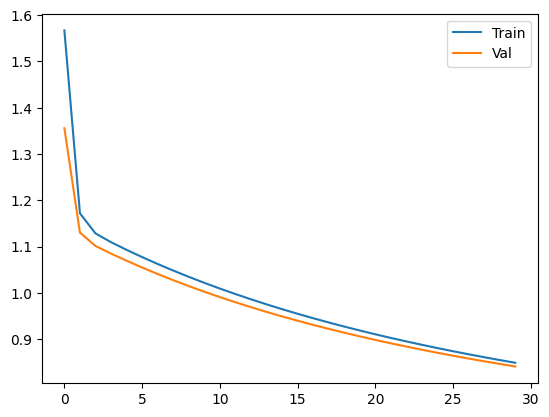

In [ ]:
plt.plot(loss_5, label = 'Train')
plt.plot(loss_val5, label = 'Val')
plt.legend()

In [ ]:
X_test, y_test = np.array(mitbih_test)[:, :-1], np.array(mitbih_test)[:, -1].astype(int)

In [ ]:
model.eval()
with torch.no_grad():
    predicted = model(torch.Tensor(X_test))
    mse = mean_squared_error(predicted, y_test)
print(f'Final MSE: {mse:.4f}')

Final MSE: 0.8393


Basic tree boosting and forest models

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_tree = DecisionTreeClassifier()
model_boost = GradientBoostingClassifier()
model_forest = RandomForestClassifier()

In [ ]:
model_tree.fit(X_train,y_train)
model_boost.fit(X_train,y_train)
model_forest.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
pred_tree = model_tree.predict(X_test)
pred_boost = model_boost.predict(X_test)
pred_forest = model_forest.predict(X_test)

In [ ]:
from sklearn.metrics import f1_score

Using f1 score because of our class disbalance

In [ ]:
print(f"f1 metric \nTree:{f1_score(pred_tree,y_test, average='micro')}\nBoosting:{f1_score(pred_boost,y_test, average='micro')}\nForest:{f1_score(pred_forest,y_test, average='micro')}")

f1 metric 
Tree:0.9521264446576219
Boosting:0.9630898542780137
Forest:0.9735050934173861


In [ ]:
%pip install optuna
from catboost import CatBoostClassifier
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

In [ ]:
def objective_cb_f1(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
        "random_strength": trial.suggest_loguniform("random_strength", 1e-3, 10.0),
        "bagging_temperature": trial.suggest_loguniform("bagging_temperature", 0.01, 10.0),
        "border_count": trial.suggest_int("border_count", 1, 255),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),
        "loss_function": "MultiClass",
        "task_type": "GPU",
        "devices": "0:1",
        "verbose": 0,
        "random_seed": 42
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=(X_test, y_test))

    preds = model.predict(X_test)

    # F1-score (macro) for disbalanced data
    score = f1_score(y_test, preds, average='macro')


    return -score

study_cb = optuna.create_study(direction="minimize")
study_cb.optimize(objective_cb_f1, n_trials=50)

print("Best CatBoost params:", study_cb.best_params)
print("Best CatBoost F1-Score:", -study_cb.best_value)

[I 2025-03-20 12:38:56,718] A new study created in memory with name: no-name-4a721a7f-855a-41ea-bc9b-34041d03760f
[I 2025-03-20 12:39:03,457] Trial 0 finished with value: -0.7893392451402343 and parameters: {'iterations': 307, 'depth': 4, 'learning_rate': 0.11895554321639411, 'random_strength': 0.014511029179315519, 'bagging_temperature': 8.88594525807979, 'border_count': 105, 'l2_leaf_reg': 0.008473053198670335}. Best is trial 0 with value: -0.7893392451402343.
[I 2025-03-20 12:39:26,823] Trial 1 finished with value: -0.8997272331916679 and parameters: {'iterations': 897, 'depth': 9, 'learning_rate': 0.059309680637875326, 'random_strength': 1.8859305804338211, 'bagging_temperature': 0.44749446061951176, 'border_count': 104, 'l2_leaf_reg': 0.0014022218451053576}. Best is trial 1 with value: -0.8997272331916679.
[I 2025-03-20 12:39:35,274] Trial 2 finished with value: -0.8582271240376347 and parameters: {'iterations': 831, 'depth': 6, 'learning_rate': 0.05980043946237484, 'random_streng

Best CatBoost params: {'iterations': 869, 'depth': 9, 'learning_rate': 0.09346318063544509, 'random_strength': 0.009280683817626017, 'bagging_temperature': 0.17225843483572442, 'border_count': 134, 'l2_leaf_reg': 0.9449894803823506}
Best CatBoost F1-Score: 0.9059688097384108



Топ-10 лучших конфигураций по F1-score:



,iterations,depth,learning_rate,random_strength,bagging_temperature,border_count,l2_leaf_reg,F1-Score
19,869,9,0.0935,0.0093,0.1723,134,0.9450,0.9060
25,871,7,0.1003,0.0032,0.0608,118,0.9038,0.9035
22,753,7,0.1706,0.0169,0.0560,147,0.8664,0.9031
13,990,7,0.2926,0.1269,0.0888,52,0.3730,0.9025
44,820,10,0.1007,0.0860,0.0832,83,0.4618,0.9024
41,925,8,0.1704,0.0345,0.0722,143,0.8103,0.9022
42,903,8,0.1774,0.0382,0.0339,146,0.3606,0.9022
21,910,8,0.1755,0.0294,0.0640,144,0.7199,0.9018
46,747,10,0.1220,0.1165,0.4325,47,0.4237,0.9015
11,963,8,0.2937,0.1074,0.1102,84,0.4787,0.9015


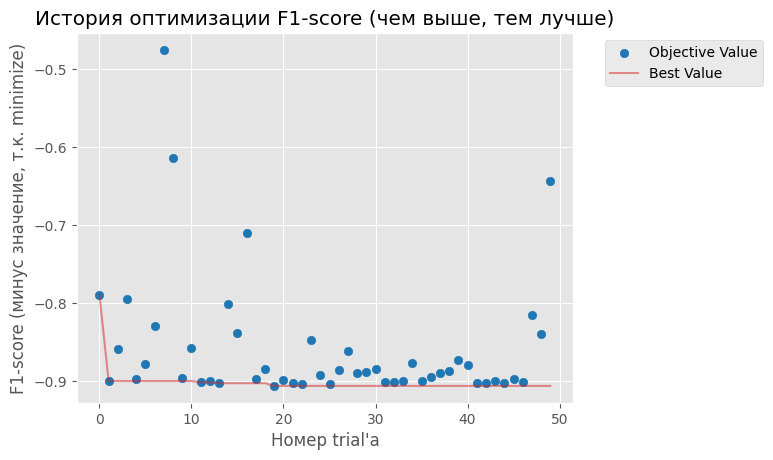

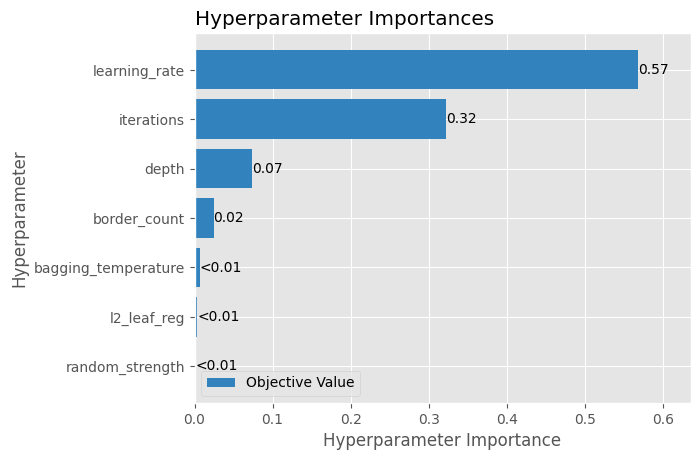

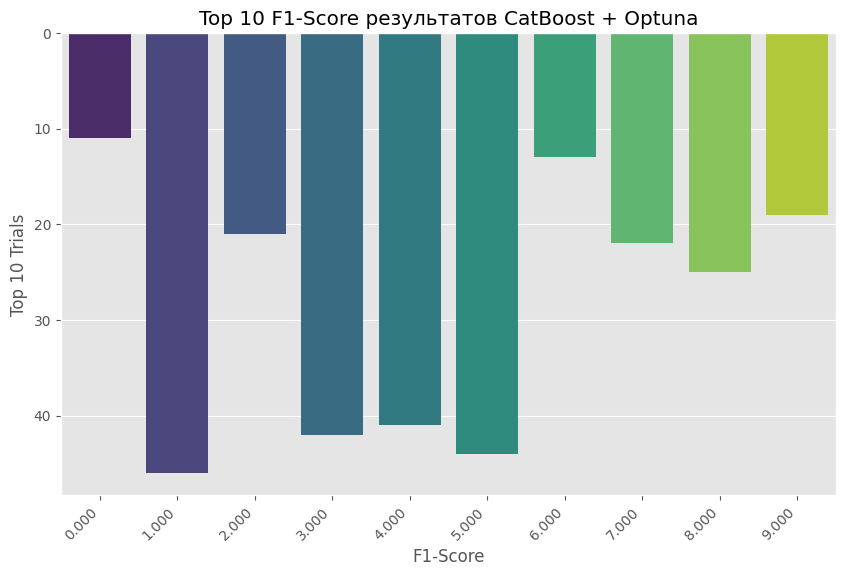

In [ ]:
def plot_optimization_history(study):
    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.title("История оптимизации F1-score (чем выше, тем лучше)")
    plt.ylabel("F1-score (минус значение, т.к. minimize)")  # это -F1
    plt.xlabel("Номер trial'a")
    plt.show()

def plot_param_importance(study):
    optuna.visualization.matplotlib.plot_param_importances(study)

    plt.show()

def display_top_trials_f1(study, top_n=10):
    trials_df = pd.DataFrame([
        {
            **t.params,
            "F1-Score": -t.value
        }
        for t in study.trials
        if t.value is not None
    ])

    top_trials = trials_df.sort_values(by="F1-Score", ascending=False).head(top_n)

    print(f"\nТоп-{top_n} лучших конфигураций по F1-score:\n")
    display(top_trials.style.background_gradient(cmap="Blues").format(precision=4))

    return top_trials


def plot_top10_f1(top_df):
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_df["Score"], y=top_df.index, palette="viridis")
    plt.xticks(rotation=45, ha="right")


    plt.gca().get_xticklabels()
    plt.gca().set_xticklabels([f"{x:.3f}" for x in plt.gca().get_xticks()])
    plt.xlabel("F1-Score")
    plt.ylabel("Top 10 Trials")
    plt.title("Top 10 F1-Score результатов CatBoost + Optuna")
    plt.gca().invert_yaxis()
    plt.show()


top_10_f1 = display_top_trials_f1(study_cb)


plot_optimization_history(study_cb)
plot_param_importance(study_cb)
plot_top10_f1(top_10_f1.rename(columns={"F1-Score": "Score"}))

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

def objective_cb_timeseries_split(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
        "random_strength": trial.suggest_loguniform("random_strength", 1e-3, 10.0),
        "bagging_temperature": trial.suggest_loguniform("bagging_temperature", 0.01, 10.0),
        "border_count": trial.suggest_int("border_count", 1, 255),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),
        "loss_function": "MultiClass",
        "task_type": "GPU",
        "devices": "0:1",
        "verbose": 0,
        "random_seed": 42,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    f1_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = CatBoostClassifier(**param)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred, average='macro')
        f1_scores.append(score)

    avg_f1 = np.mean(f1_scores)


    return -avg_f1

In [ ]:
study_timeseries = optuna.create_study(direction="minimize")
study_timeseries.optimize(objective_cb_timeseries_split, n_trials=50)

print("=== Лучшие параметры по TimeSeriesSplit ===")
print("Best F1-Score:", -study_timeseries.best_value)
print("Best Params:", study_timeseries.best_params)

[I 2025-03-20 13:12:55,753] A new study created in memory with name: no-name-cd59b768-5ed3-4f2e-a377-a22c8987d673
[I 2025-03-20 13:13:14,888] Trial 0 finished with value: -0.6518986240762503 and parameters: {'iterations': 334, 'depth': 6, 'learning_rate': 0.00809573907274982, 'random_strength': 0.5739370955027707, 'bagging_temperature': 0.45830063187582865, 'border_count': 115, 'l2_leaf_reg': 0.9925809278175621}. Best is trial 0 with value: -0.6518986240762503.
[I 2025-03-20 13:13:39,465] Trial 1 finished with value: -0.7496833486259391 and parameters: {'iterations': 399, 'depth': 6, 'learning_rate': 0.027326954934164253, 'random_strength': 0.0010889353688819457, 'bagging_temperature': 7.27063578236204, 'border_count': 232, 'l2_leaf_reg': 0.41733974237607596}. Best is trial 1 with value: -0.7496833486259391.
[I 2025-03-20 13:13:54,640] Trial 2 finished with value: -0.8369282803046343 and parameters: {'iterations': 169, 'depth': 6, 'learning_rate': 0.08035124132452813, 'random_strength'

=== Лучшие параметры по TimeSeriesSplit ===
Best F1-Score: 0.8977049366906819
Best Params: {'iterations': 951, 'depth': 8, 'learning_rate': 0.21045996165847236, 'random_strength': 0.004936042240998391, 'bagging_temperature': 0.057696214535848604, 'border_count': 98, 'l2_leaf_reg': 0.2721375499260343}


In [ ]:

best_params = study_timeseries.best_params
best_params.update({
    "loss_function": "MultiClass",
    "verbose": 0
})

final_model = CatBoostClassifier(**best_params)
final_model.fit(X_train, y_train)


y_test_pred = final_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"\nFinal F1-score на тестовой выборке: {test_f1:.4f}")


Final F1-score на тестовой выборке: 0.9052


,iterations,depth,learning_rate,random_strength,bagging_temperature,border_count,l2_leaf_reg,F1-Score
35,951,8,0.2105,0.0049,0.0577,98,0.2721,0.8977
41,775,9,0.1700,0.0014,0.1351,50,0.1497,0.8973
22,981,10,0.1595,0.0025,0.2137,58,0.0095,0.8968
45,972,9,0.1893,0.0071,0.0633,45,0.1383,0.8964
8,782,8,0.1555,0.2564,0.5622,29,0.1252,0.8964
31,948,9,0.1948,0.0047,0.9501,68,0.0496,0.8960
24,797,9,0.1676,0.0026,0.8422,59,0.1600,0.8958
36,961,7,0.2238,0.0103,0.0472,99,0.3548,0.8955
21,909,9,0.1527,0.0054,1.0265,71,0.0375,0.8953
10,994,10,0.2958,0.0427,0.0123,26,0.0056,0.8953


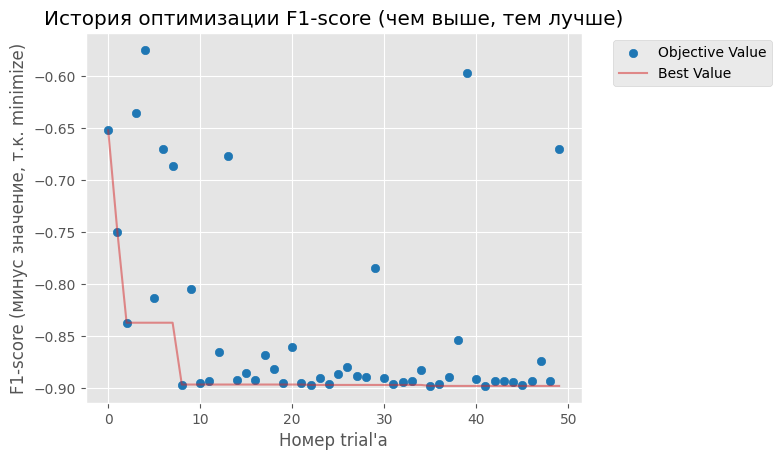

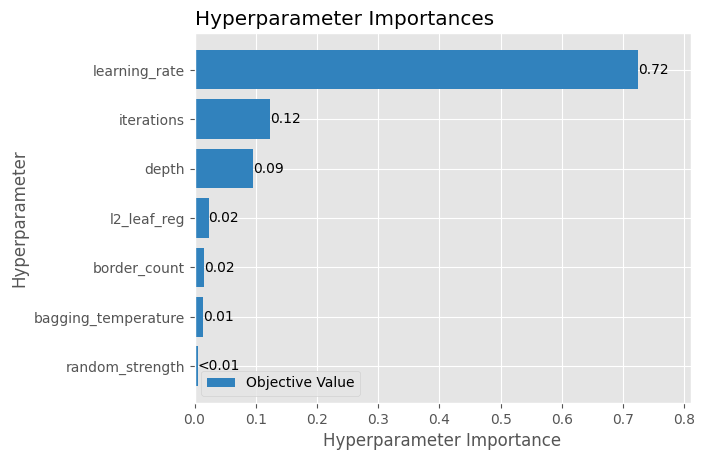

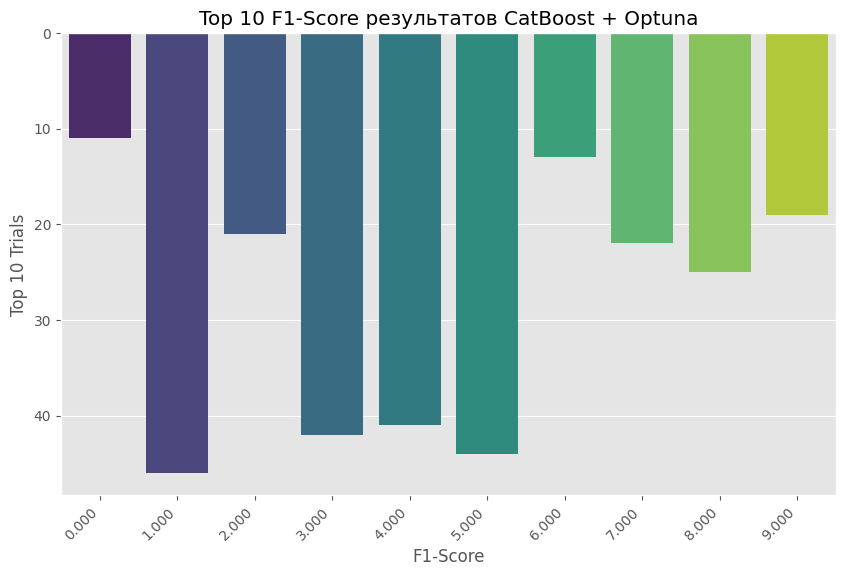

In [ ]:
def display_top_trials_f1(study, top_n=10):
    import pandas as pd
    from IPython.display import display

    trials_df = pd.DataFrame([
        {
            **t.params,
            "F1-Score": -t.value
        }
        for t in study.trials
        if t.value is not None
    ])

    top_trials = trials_df.sort_values(by="F1-Score", ascending=False).head(top_n)

    display(top_trials.style.background_gradient(cmap="Blues").format(precision=4))
    return top_trials

top_trials = display_top_trials_f1(study_timeseries)



plot_optimization_history(study_timeseries)
plot_param_importance(study_timeseries)
plot_top10_f1(top_10_f1.rename(columns={"F1-Score": "Score"}))